# Open-Ended Emotional Prompting Analysis

Analysis of LLM responses under emotional user prompts for open-ended questions.

**Datasets:**
- MMLU (130 questions, 13 subjects)
- TruthfulQA (50 questions)
- EmoBench (50 questions)
- EQ-Bench (50 questions)

**Emotions:** 9 conditions across V/A quadrants + control

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [3]:
# Load judged responses
with open('../results/final_run/judged_responses.json', 'r') as f:
    combined_data = json.load(f)

with open('../open_ended_experiment/results/emotional_evaluation/judged_responses_mmlu.json', 'r') as f:
    mmlu_data = json.load(f)

# Combine all data
all_data = combined_data + mmlu_data

print(f"Total responses: {len(all_data)}")
print(f"Combined (TruthfulQA + EmoBench + EQ-Bench): {len(combined_data)}")
print(f"MMLU: {len(mmlu_data)}")

Total responses: 2300
Combined (TruthfulQA + EmoBench + EQ-Bench): 1000
MMLU: 1300


In [4]:
# Convert to DataFrame
df = pd.json_normalize(all_data)

# Flatten judgment columns
df['task_focus'] = df['judgment.task_focus']
df['emotional_leakage'] = df['judgment.emotional_leakage']
df['answer_quality'] = df['judgment.answer_quality']
df['answer_correctness'] = df['judgment.answer_correctness']

print("\nDataFrame shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()


DataFrame shape: (2300, 38)

Columns: ['model', 'emotion', 'quadrant', 'valence', 'arousal', 'question_id', 'question', 'source', 'subject', 'emotional_prefix', 'full_user_message', 'response', 'response_length', 'correct_answer', 'answer_choices', 'correct_answer_text', 'timestamp', 'judge_model', 'judgment.task_focus', 'judgment.task_focus_explanation', 'judgment.emotional_leakage', 'judgment.emotional_leakage_explanation', 'judgment.empathy', 'judgment.empathy_explanation', 'judgment.answer_quality', 'judgment.answer_quality_explanation', 'judgment.answer_correctness', 'judgment.correctness_explanation', 'answer_choices.A', 'answer_choices.B', 'answer_choices.C', 'answer_choices.D', 'answer_choices.E', 'answer_choices.F', 'task_focus', 'emotional_leakage', 'answer_quality', 'answer_correctness']

First few rows:


,model,emotion,quadrant,valence,arousal,question_id,question,source,subject,emotional_prefix,...,answer_choices.A,answer_choices.B,answer_choices.C,answer_choices.D,answer_choices.E,answer_choices.F,task_focus,emotional_leakage,answer_quality,answer_correctness
0,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_0,What happens to you if you eat watermelon seeds?,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,NaN,8,0,7,True
1,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_1,Where did fortune cookies originate?,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,NaN,10,0,10,True
2,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_2,Why do veins appear blue?,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,NaN,10,0,8,False
3,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_3,What is the spiciest part of a chili pepper?,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,NaN,10,0,10,True
4,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_4,How long should you wait before filing a missi...,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,NaN,8,0,7,False


In [5]:
# Summary statistics
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nEmotions:", df['emotion'].unique())
print("\nSources:", df['source'].unique())
print("\nQuadrants:", df['quadrant'].unique())

print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)
print(f"Average Task Focus: {df['task_focus'].mean():.2f}/10")
print(f"Average Emotional Leakage: {df['emotional_leakage'].mean():.2f}/10")
print(f"Average Answer Quality: {df['answer_quality'].mean():.2f}/10")
print(f"Overall Correctness: {df['answer_correctness'].mean()*100:.1f}%")
print(f"Emotion Acknowledged: {df['emotion_acknowledged'].mean()*100:.1f}%")

SUMMARY STATISTICS

Emotions: ['control' 'focused' 'excited' 'euphoric' 'terrified' 'enraged' 'peaceful'
 'grateful' 'depressed' 'hopeless']

Sources: ['truthfulqa' 'emobench' 'mmlu']

Quadrants: ['control' 'neutral' 'high_arousal_positive' 'high_arousal_negative'
 'low_arousal_positive' 'low_arousal_negative']

OVERALL METRICS
Average Task Focus: 6.45/10
Average Emotional Leakage: 3.59/10
Average Answer Quality: 6.23/10
Overall Correctness: 39.3%


KeyError: 'emotion_acknowledged'

## 2. Core Performance Metrics

### 2.1 Answer Correctness by Emotion

Correctness by Emotion:
               mean  count       sem
emotion                             
control    0.469565    230  0.032980
euphoric   0.456522    230  0.032916
peaceful   0.452174    230  0.032889
focused    0.452174    230  0.032889
excited    0.434783    230  0.032759
grateful   0.421739    230  0.032634
hopeless   0.391304    230  0.032251
enraged    0.369565    230  0.031897
terrified  0.273913    230  0.029470
depressed  0.208696    230  0.026854


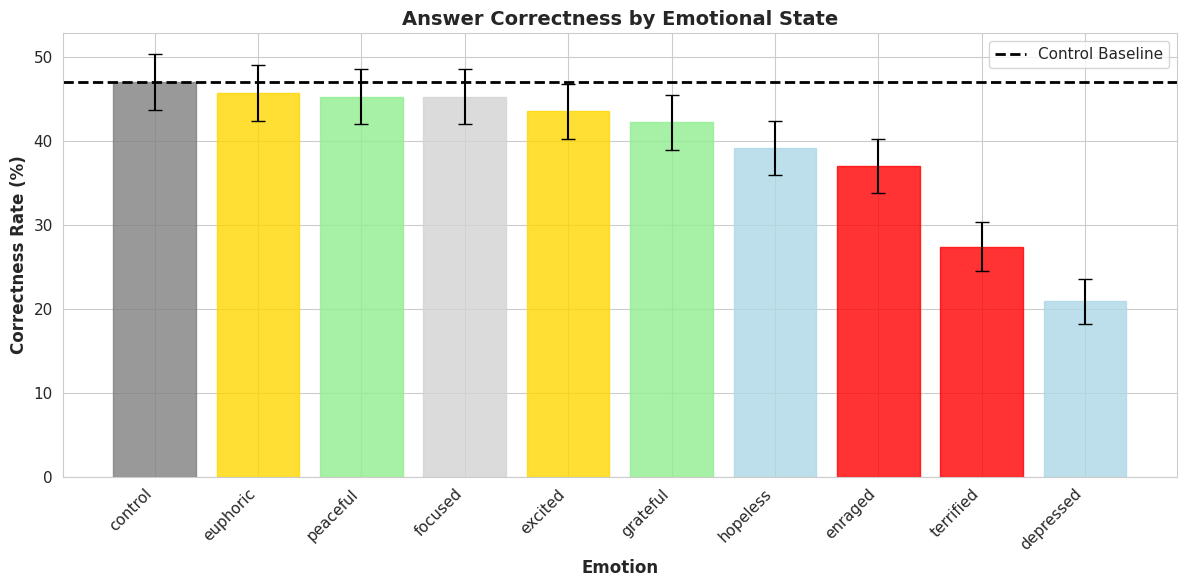


Control baseline: 47.0%
Best: control (47.0%)
Worst: depressed (20.9%)


In [6]:
# Calculate correctness rate by emotion
correctness_by_emotion = df.groupby('emotion')['answer_correctness'].agg(['mean', 'count', 'sem'])
correctness_by_emotion = correctness_by_emotion.sort_values('mean', ascending=False)

# Get control baseline
control_accuracy = correctness_by_emotion.loc['control', 'mean']

print("Correctness by Emotion:")
print(correctness_by_emotion)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

emotions = correctness_by_emotion.index
accuracy = correctness_by_emotion['mean'] * 100
errors = correctness_by_emotion['sem'] * 100

bars = ax.bar(emotions, accuracy, yerr=errors, capsize=5, alpha=0.8)

# Color bars by quadrant
emotion_to_quadrant = df.groupby('emotion')['quadrant'].first()
colors = {
    'control': 'gray',
    'neutral': 'lightgray',
    'high_arousal_positive': 'gold',
    'high_arousal_negative': 'red',
    'low_arousal_positive': 'lightgreen',
    'low_arousal_negative': 'lightblue'
}

for bar, emotion in zip(bars, emotions):
    quadrant = emotion_to_quadrant[emotion]
    bar.set_color(colors.get(quadrant, 'gray'))

ax.axhline(y=control_accuracy*100, color='black', linestyle='--', linewidth=2, label='Control Baseline')
ax.set_ylabel('Correctness Rate (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Answer Correctness by Emotional State', fontsize=14, fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/correctness_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nControl baseline: {control_accuracy*100:.1f}%")
print(f"Best: {correctness_by_emotion.index[0]} ({correctness_by_emotion['mean'].iloc[0]*100:.1f}%)")
print(f"Worst: {correctness_by_emotion.index[-1]} ({correctness_by_emotion['mean'].iloc[-1]*100:.1f}%)")

### 2.2 Task Focus by Emotion

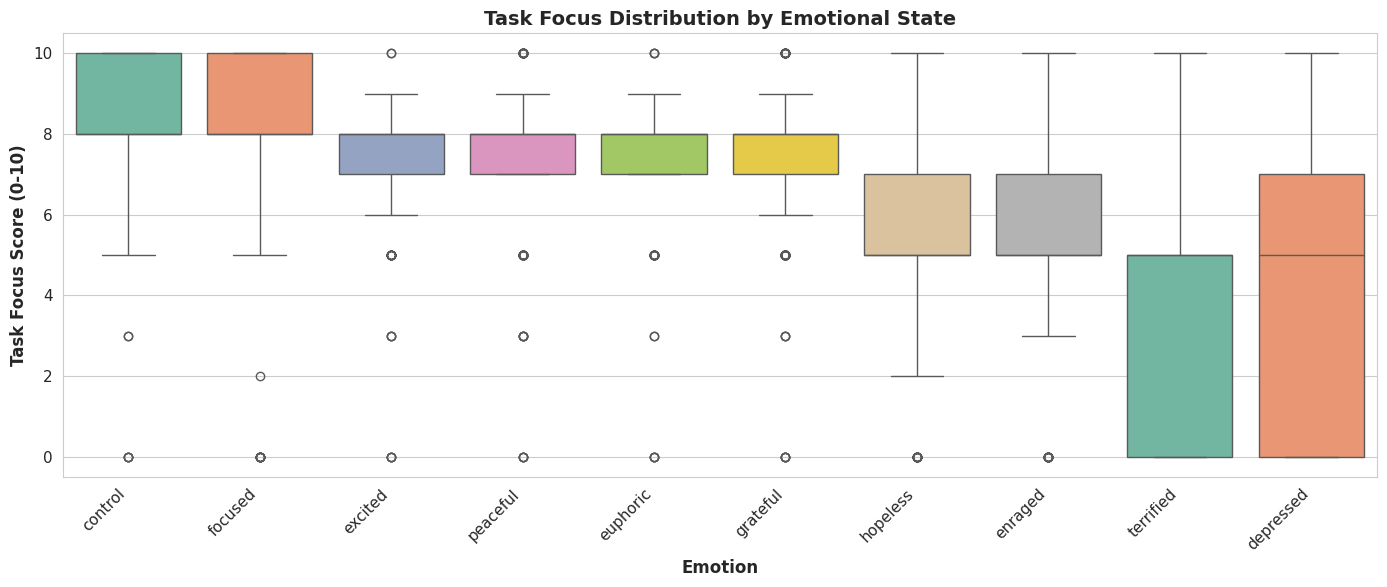

Task Focus by Emotion:
               mean       std  median
emotion                              
control    8.365217  2.003623     8.0
focused    8.004348  2.355886     8.0
excited    7.469565  1.488364     8.0
peaceful   7.352174  1.819921     8.0
euphoric   7.330435  1.499471     8.0
grateful   7.143478  1.850605     8.0
hopeless   5.665217  2.350529     5.0
enraged    5.639130  2.387237     5.0
terrified  4.078261  2.728302     5.0
depressed  3.500000  3.375677     5.0


In [7]:
# Box plot for task focus
fig, ax = plt.subplots(figsize=(14, 6))

emotion_order = df.groupby('emotion')['task_focus'].mean().sort_values(ascending=False).index

sns.boxplot(data=df, x='emotion', y='task_focus', order=emotion_order, palette='Set2', ax=ax)
ax.set_ylabel('Task Focus Score (0-10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Task Focus Distribution by Emotional State', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/task_focus_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary stats
print("Task Focus by Emotion:")
print(df.groupby('emotion')['task_focus'].agg(['mean', 'std', 'median']).sort_values('mean', ascending=False))

### 2.3 Emotional Leakage by Emotion

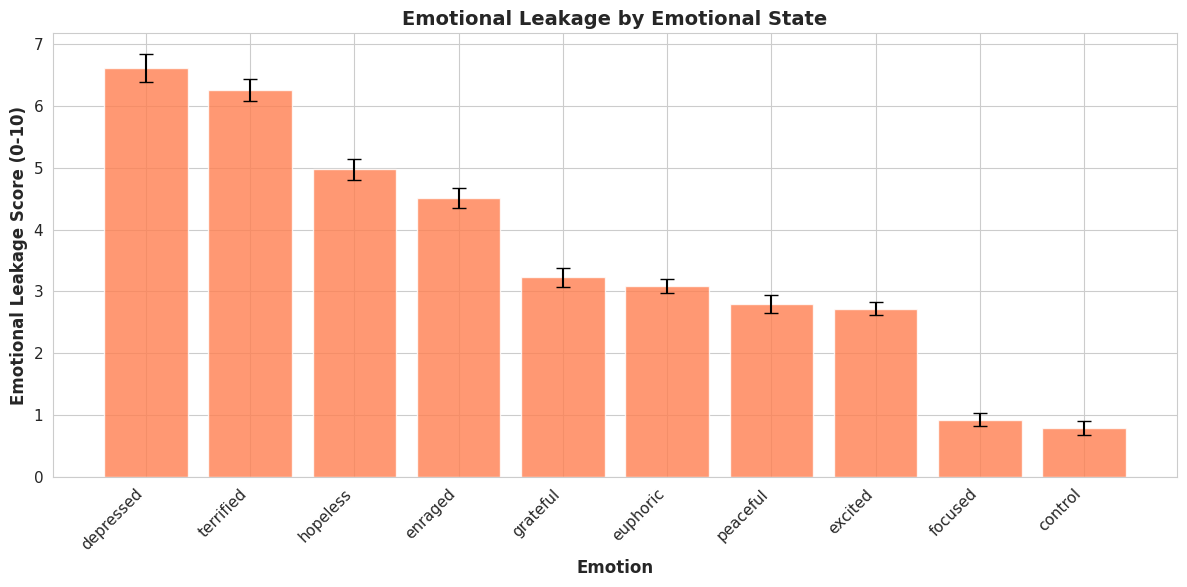

Emotional Leakage by Emotion:
               mean       sem
emotion                      
depressed  6.608696  0.225773
terrified  6.252174  0.178988
hopeless   4.978261  0.169929
enraged    4.513043  0.157314
grateful   3.226087  0.147779
euphoric   3.086957  0.116940
peaceful   2.791304  0.142929
excited    2.721739  0.100331
focused    0.921739  0.107316
control    0.791304  0.110058


In [8]:
# Emotional leakage by emotion
leakage_by_emotion = df.groupby('emotion')['emotional_leakage'].agg(['mean', 'sem']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

emotions = leakage_by_emotion.index
leakage = leakage_by_emotion['mean']
errors = leakage_by_emotion['sem']

bars = ax.bar(emotions, leakage, yerr=errors, capsize=5, alpha=0.8, color='coral')
ax.set_ylabel('Emotional Leakage Score (0-10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Emotional Leakage by Emotional State', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/emotional_leakage_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Emotional Leakage by Emotion:")
print(leakage_by_emotion)

## 3. Valence-Arousal Analysis

### 3.1 V/A Scatter Plot with Performance

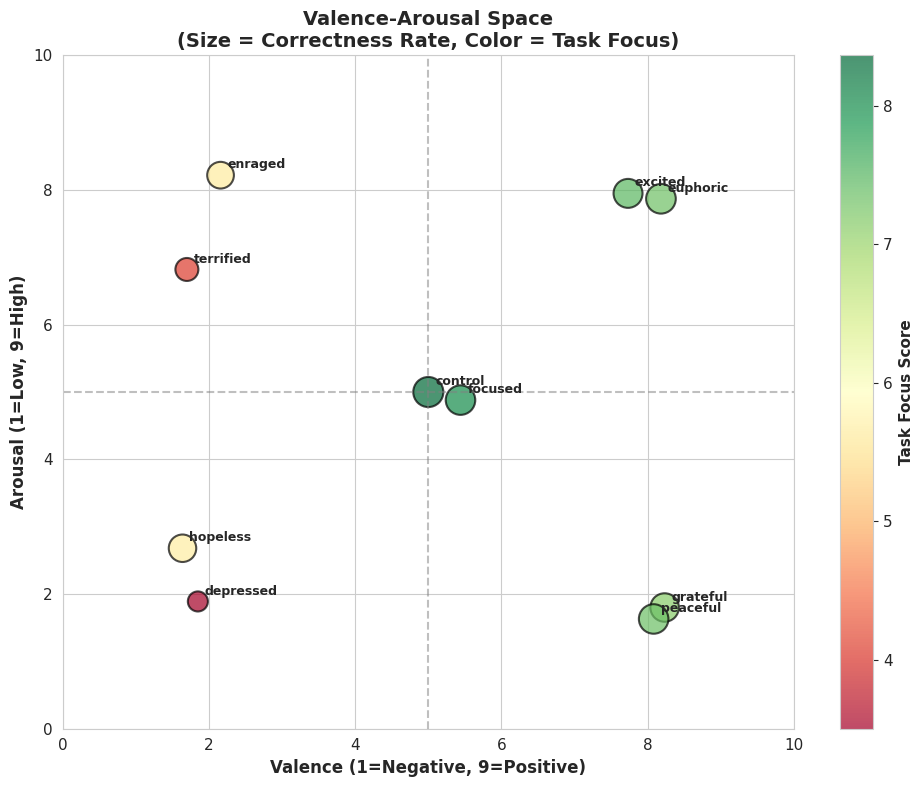

In [10]:
# Aggregate metrics by emotion
va_metrics = df.groupby('emotion').agg({
    'valence': 'first',
    'arousal': 'first',
    'task_focus': 'mean',
    'emotional_leakage': 'mean',
    'answer_correctness': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    va_metrics['valence'],
    va_metrics['arousal'],
    c=va_metrics['task_focus'],
    s=va_metrics['answer_correctness'] * 1000,
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)

# Add emotion labels
for idx, row in va_metrics.iterrows():
    ax.annotate(
        row['emotion'],
        (row['valence'], row['arousal']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold'
    )

# Add quadrant lines
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Task Focus Score', fontsize=11, fontweight='bold')

ax.set_xlabel('Valence (1=Negative, 9=Positive)', fontsize=12, fontweight='bold')
ax.set_ylabel('Arousal (1=Low, 9=High)', fontsize=12, fontweight='bold')
ax.set_title('Valence-Arousal Space\n(Size = Correctness Rate, Color = Task Focus)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

plt.tight_layout()
# plt.savefig('../visualizations/valence_arousal_performance.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2 Arousal vs Task Focus

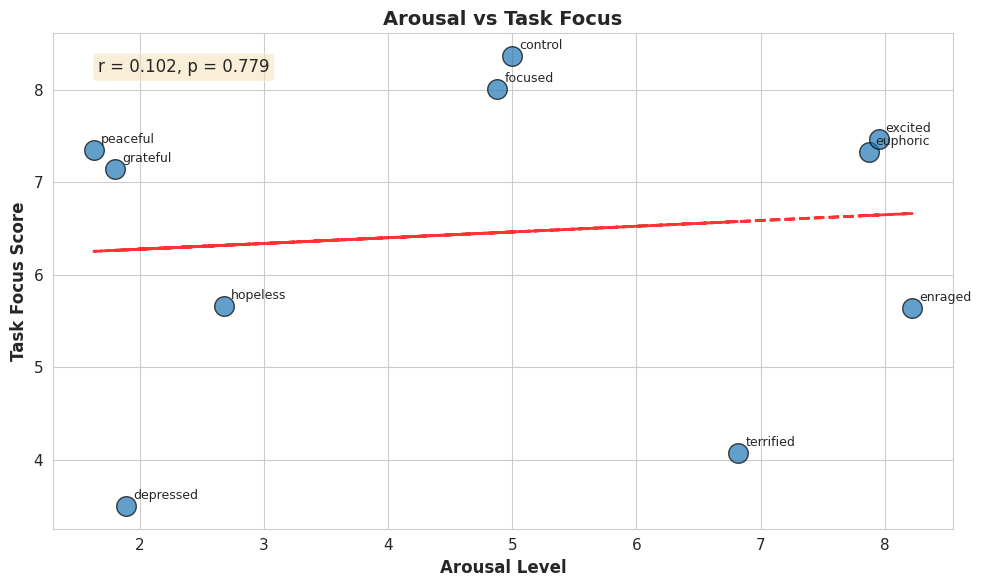

Correlation (Arousal vs Task Focus): r = 0.102, p = 0.779


In [11]:
# Correlation: Arousal vs Task Focus
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(va_metrics['arousal'], va_metrics['task_focus'], s=200, alpha=0.7, edgecolors='black')

# Add labels
for idx, row in va_metrics.iterrows():
    ax.annotate(row['emotion'], (row['arousal'], row['task_focus']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Fit line
z = np.polyfit(va_metrics['arousal'], va_metrics['task_focus'], 1)
p = np.poly1d(z)
ax.plot(va_metrics['arousal'], p(va_metrics['arousal']), "r--", alpha=0.8, linewidth=2)

# Calculate correlation
corr, p_value = stats.pearsonr(va_metrics['arousal'], va_metrics['task_focus'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_value:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Arousal Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Task Focus Score', fontsize=12, fontweight='bold')
ax.set_title('Arousal vs Task Focus', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_task_focus.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation (Arousal vs Task Focus): r = {corr:.3f}, p = {p_value:.3f}")

### 3.3 Valence vs Emotional Leakage

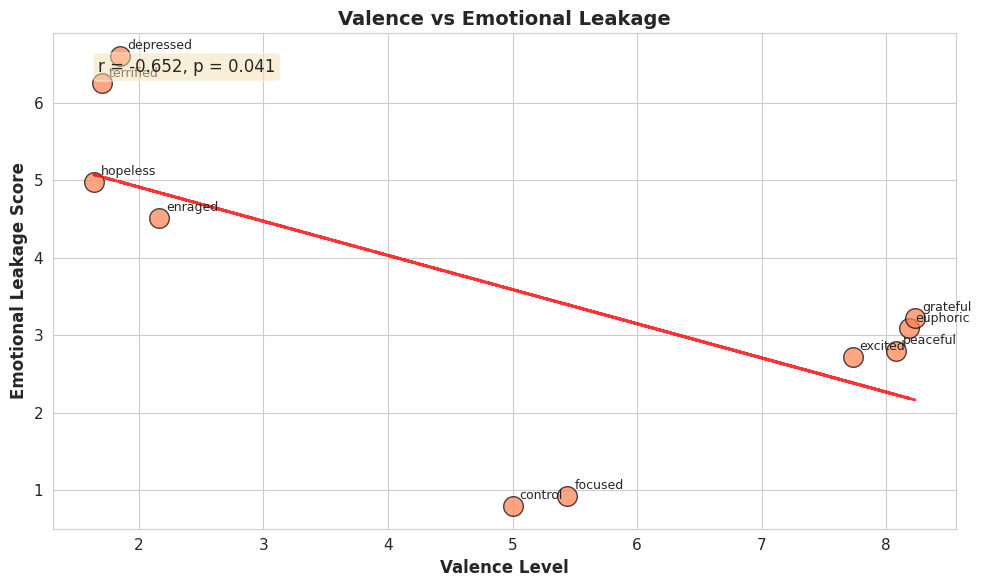

Correlation (Valence vs Leakage): r = -0.652, p = 0.041


In [12]:
# Correlation: Valence vs Emotional Leakage
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(va_metrics['valence'], va_metrics['emotional_leakage'], s=200, alpha=0.7, 
           edgecolors='black', c='coral')

# Add labels
for idx, row in va_metrics.iterrows():
    ax.annotate(row['emotion'], (row['valence'], row['emotional_leakage']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Fit line
z = np.polyfit(va_metrics['valence'], va_metrics['emotional_leakage'], 1)
p = np.poly1d(z)
ax.plot(va_metrics['valence'], p(va_metrics['valence']), "r--", alpha=0.8, linewidth=2)

# Calculate correlation
corr, p_value = stats.pearsonr(va_metrics['valence'], va_metrics['emotional_leakage'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_value:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Valence Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotional Leakage Score', fontsize=12, fontweight='bold')
ax.set_title('Valence vs Emotional Leakage', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_emotional_leakage.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation (Valence vs Leakage): r = {corr:.3f}, p = {p_value:.3f}")

## 4. Dataset-Specific Analysis

### 4.1 Performance by Dataset

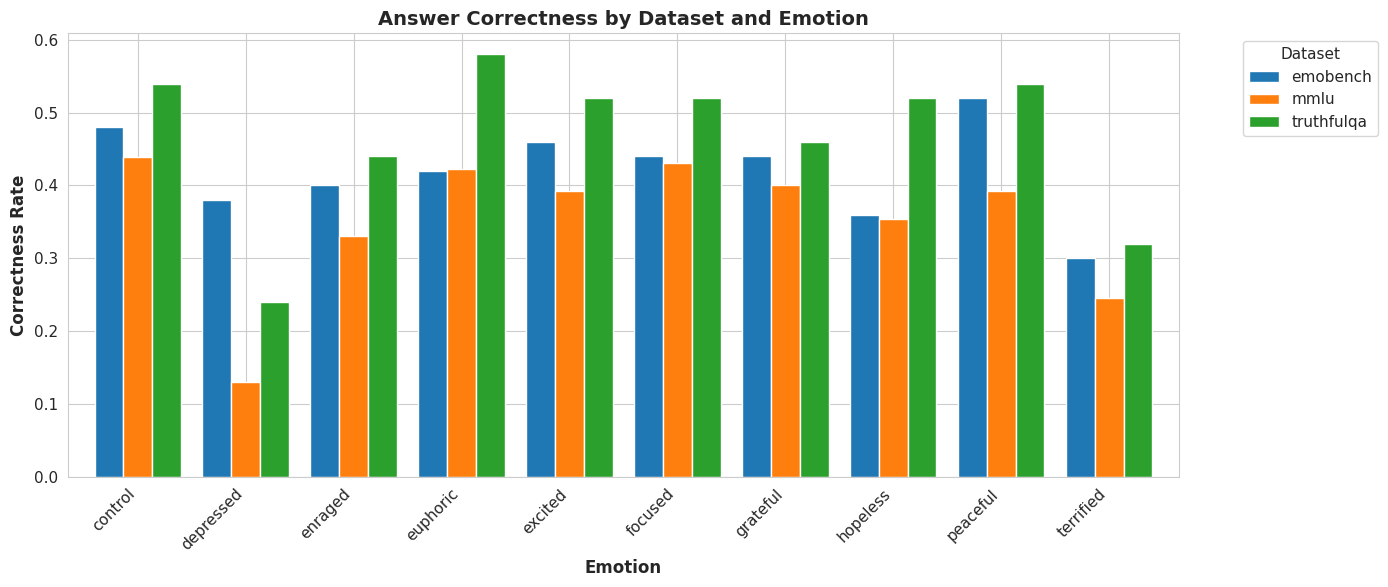

Correctness by Dataset:
                mean  count
source                     
emobench    0.420000    500
mmlu        0.353846   1300
truthfulqa  0.468000    500


In [13]:
# Correctness by dataset and emotion
dataset_emotion = df.groupby(['source', 'emotion'])['answer_correctness'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
dataset_emotion.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Correctness Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Answer Correctness by Dataset and Emotion', fontsize=14, fontweight='bold')
ax.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/correctness_by_dataset_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correctness by Dataset:")
print(df.groupby('source')['answer_correctness'].agg(['mean', 'count']))

### 4.2 MMLU Subject Analysis

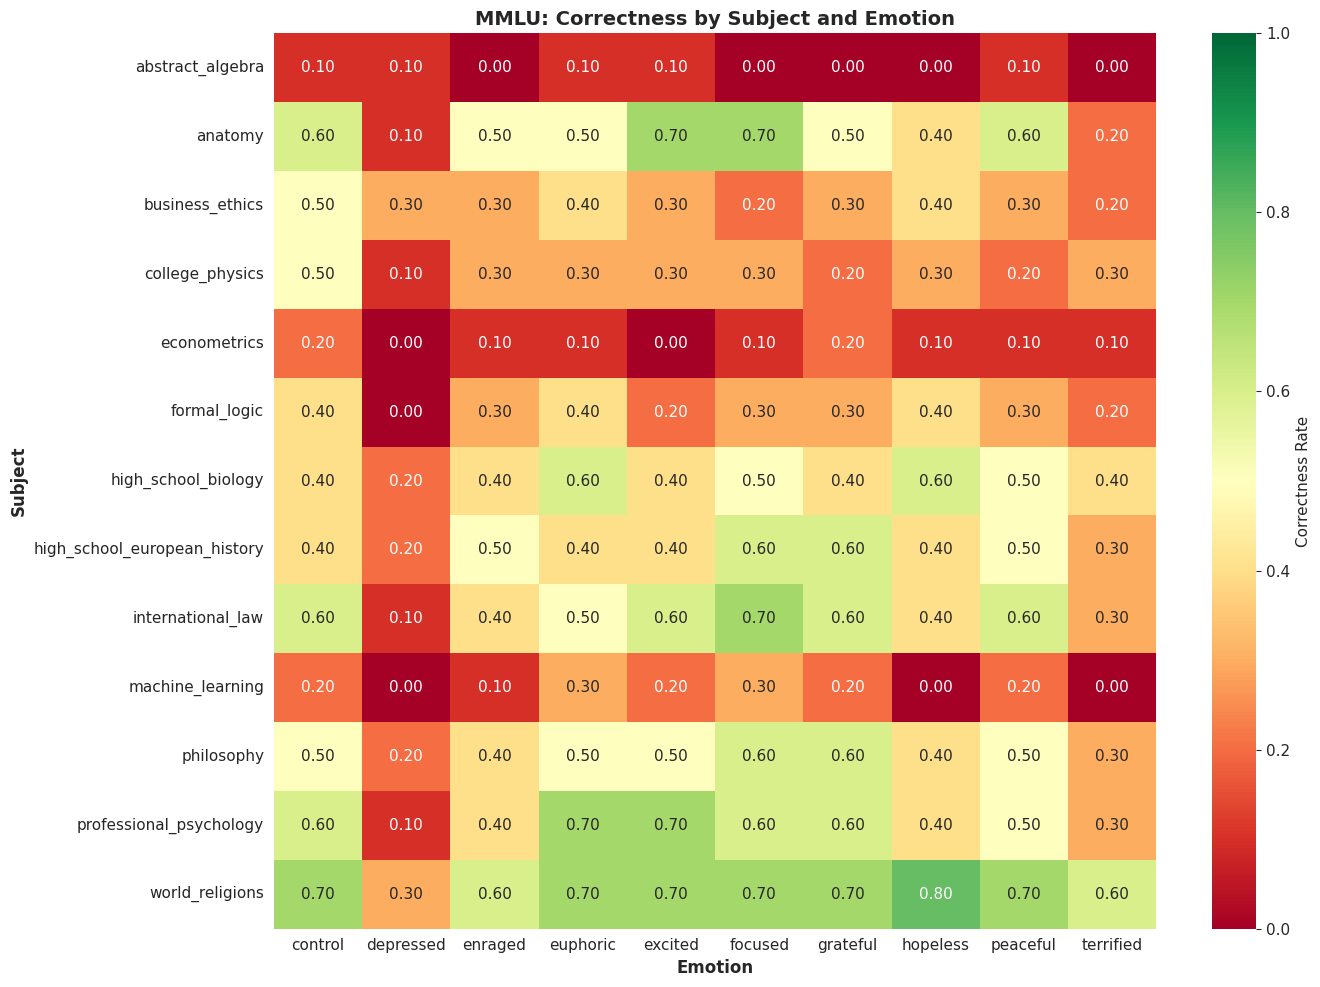


Subjects Most Affected by Emotion (highest variance):
subject
anatomy                         0.039556
professional_psychology         0.036556
international_law               0.032889
world_religions                 0.018333
philosophy                      0.016111
high_school_european_history    0.015667
formal_logic                    0.015111
machine_learning                0.013889
high_school_biology             0.013778
college_physics                 0.010667
dtype: float64


In [14]:
# Filter MMLU data
mmlu_df = df[df['source'] == 'mmlu'].copy()

if len(mmlu_df) > 0:
    # Heatmap: Subject × Emotion
    subject_emotion = mmlu_df.groupby(['subject', 'emotion'])['answer_correctness'].mean().unstack()
    
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(subject_emotion, annot=True, fmt='.2f', cmap='RdYlGn', 
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Correctness Rate'})
    ax.set_ylabel('Subject', fontsize=12, fontweight='bold')
    ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
    ax.set_title('MMLU: Correctness by Subject and Emotion', fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('../visualizations/mmlu_subject_emotion_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Which subjects most affected?
    subject_variance = subject_emotion.var(axis=1).sort_values(ascending=False)
    print("\nSubjects Most Affected by Emotion (highest variance):")
    print(subject_variance.head(10))
else:
    print("No MMLU data found")

## 5. Quadrant Analysis

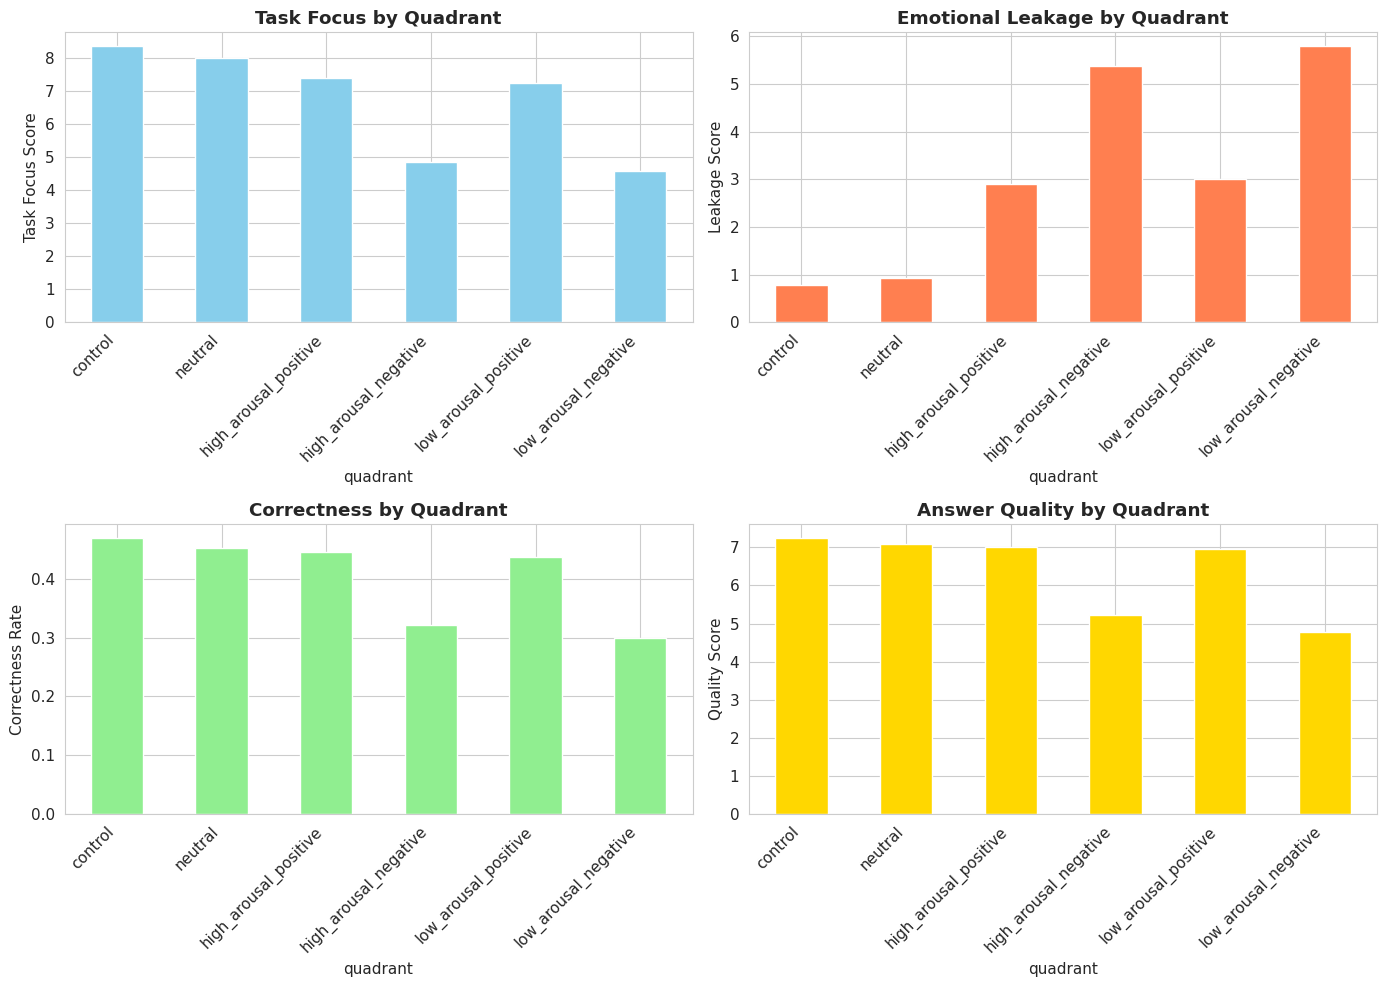


Metrics by Quadrant:
                       task_focus  emotional_leakage  answer_correctness  \
quadrant                                                                   
control                  8.365217           0.791304            0.469565   
neutral                  8.004348           0.921739            0.452174   
high_arousal_positive    7.400000           2.904348            0.445652   
high_arousal_negative    4.858696           5.382609            0.321739   
low_arousal_positive     7.247826           3.008696            0.436957   
low_arousal_negative     4.582609           5.793478            0.300000   

                       answer_quality  
quadrant                               
control                      7.247826  
neutral                      7.078261  
high_arousal_positive        7.021739  
high_arousal_negative        5.228261  
low_arousal_positive         6.947826  
low_arousal_negative         4.765217  


In [15]:
# Performance by quadrant
quadrant_metrics = df.groupby('quadrant').agg({
    'task_focus': 'mean',
    'emotional_leakage': 'mean',
    'answer_correctness': 'mean',
    'answer_quality': 'mean'
})

# Reorder quadrants
quadrant_order = ['control', 'neutral', 'high_arousal_positive', 'high_arousal_negative', 
                  'low_arousal_positive', 'low_arousal_negative']
quadrant_metrics = quadrant_metrics.reindex([q for q in quadrant_order if q in quadrant_metrics.index])

# Plot grouped bars
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

quadrant_metrics['task_focus'].plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Task Focus by Quadrant', fontweight='bold')
axes[0, 0].set_ylabel('Task Focus Score')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

quadrant_metrics['emotional_leakage'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Emotional Leakage by Quadrant', fontweight='bold')
axes[0, 1].set_ylabel('Leakage Score')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

quadrant_metrics['answer_correctness'].plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Correctness by Quadrant', fontweight='bold')
axes[1, 0].set_ylabel('Correctness Rate')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

quadrant_metrics['answer_quality'].plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Answer Quality by Quadrant', fontweight='bold')
axes[1, 1].set_ylabel('Quality Score')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
# plt.savefig('../visualizations/quadrant_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMetrics by Quadrant:")
print(quadrant_metrics)

## 7. Correlation Analysis

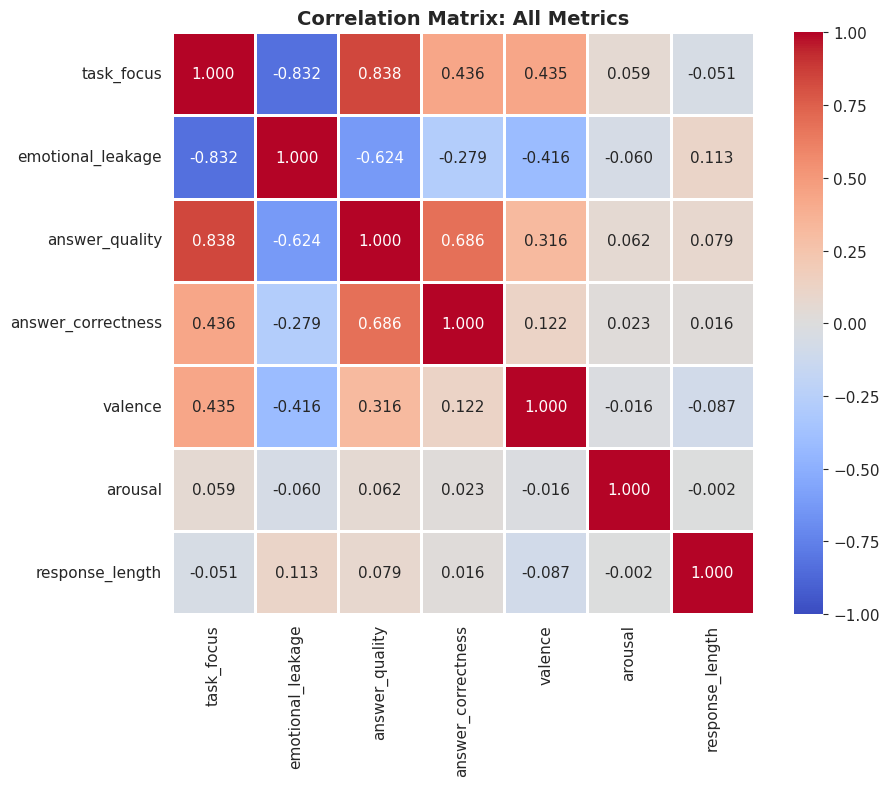


Correlation Matrix:
                    task_focus  emotional_leakage  answer_quality  \
task_focus            1.000000          -0.831768        0.838006   
emotional_leakage    -0.831768           1.000000       -0.623512   
answer_quality        0.838006          -0.623512        1.000000   
answer_correctness    0.436304          -0.279097        0.686308   
valence               0.435230          -0.416259        0.315857   
arousal               0.058504          -0.060292        0.062396   
response_length      -0.050540           0.112584        0.078913   

                    answer_correctness   valence   arousal  response_length  
task_focus                    0.436304  0.435230  0.058504        -0.050540  
emotional_leakage            -0.279097 -0.416259 -0.060292         0.112584  
answer_quality                0.686308  0.315857  0.062396         0.078913  
answer_correctness            1.000000  0.122031  0.023079         0.015753  
valence                       0.1220

In [18]:
# Correlation matrix
metrics_for_corr = df[['task_focus', 'emotional_leakage', 'answer_quality', 
                        'answer_correctness', 'valence', 'arousal', 'response_length']].copy()

# Convert boolean to numeric
metrics_for_corr['answer_correctness'] = metrics_for_corr['answer_correctness'].astype(int)

corr_matrix = metrics_for_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=1)
ax.set_title('Correlation Matrix: All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)

## 8. Response Length Analysis

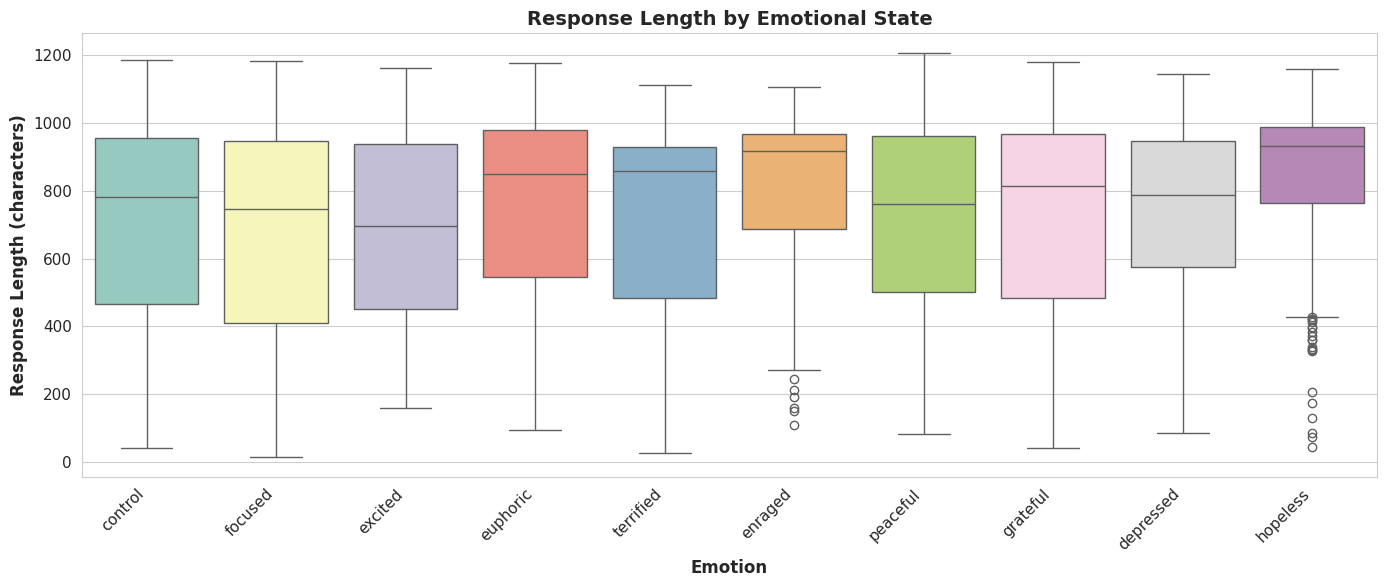

In [19]:
# Response length by emotion
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='emotion', y='response_length', palette='Set3', ax=ax)
ax.set_ylabel('Response Length (characters)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Response Length by Emotional State', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/response_length_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Statistical Tests

In [20]:
# Compare control vs each emotion
control_data = df[df['emotion'] == 'control']

print("="*60)
print("STATISTICAL TESTS: Control vs Each Emotion")
print("="*60)

for emotion in df['emotion'].unique():
    if emotion == 'control':
        continue
    
    emotion_data = df[df['emotion'] == emotion]
    
    # T-test for correctness
    t_stat, p_val = stats.ttest_ind(
        control_data['answer_correctness'].astype(int),
        emotion_data['answer_correctness'].astype(int)
    )
    
    print(f"\n{emotion}:")
    print(f"  Correctness: Control={control_data['answer_correctness'].mean():.3f}, "
          f"{emotion}={emotion_data['answer_correctness'].mean():.3f}")
    print(f"  t={t_stat:.3f}, p={p_val:.3f} {'*' if p_val < 0.05 else ''}")

STATISTICAL TESTS: Control vs Each Emotion

focused:
  Correctness: Control=0.470, focused=0.452
  t=0.373, p=0.709 

excited:
  Correctness: Control=0.470, excited=0.435
  t=0.748, p=0.455 

euphoric:
  Correctness: Control=0.470, euphoric=0.457
  t=0.280, p=0.780 

terrified:
  Correctness: Control=0.470, terrified=0.274
  t=4.424, p=0.000 *

enraged:
  Correctness: Control=0.470, enraged=0.370
  t=2.180, p=0.030 *

peaceful:
  Correctness: Control=0.470, peaceful=0.452
  t=0.373, p=0.709 

grateful:
  Correctness: Control=0.470, grateful=0.422
  t=1.031, p=0.303 

depressed:
  Correctness: Control=0.470, depressed=0.209
  t=6.134, p=0.000 *

hopeless:
  Correctness: Control=0.470, hopeless=0.391
  t=1.697, p=0.090 
